who else spent big on political-ish FB ads around the may 2022 election, and how do their patterns compare. input is v3 from notebook 04, advocacy rows only.

setup

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, sum as spark_sum, count as spark_count, countDistinct,
    when, lit, date_trunc, desc, broadcast,
)
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

spark = SparkSession.builder \
    .appName('FB_API_election_spenders') \
    .config('spark.sql.parquet.output.committer.class',
            'org.apache.parquet.hadoop.ParquetOutputCommitter') \
    .config('mapreduce.fileoutputcommitter.algorithm.version', '2') \
    .getOrCreate()

print('Master:', spark.sparkContext.master)
print('Spark version:', spark.version)

In [2]:
V3_PATH = '/user/s3348393/main/preprocessing/v3/parquet'

ELECTION_DATE = pd.Timestamp('2022-05-21')
WINDOW_START  = pd.Timestamp('2021-11-21')
WINDOW_END    = pd.Timestamp('2022-11-21')

# Consistent palette across every chart in this notebook so the same advertiser
# type reads the same colour everywhere.
GROUP_COLORS = {
    'candidate':           '#1f77b4',   # blue
    'party_org':           '#ff7f0e',   # orange
    'climate':             '#2ca02c',   # green
    'humanitarian_rights': '#d62728',   # red
    'political_advocacy':  '#9467bd',   # purple
    'cost_of_living':      '#8c564b',   # brown
}

load v3, drop candidates and parties, tag group and pre/post period, cache.

In [3]:
v3 = spark.read.parquet(V3_PATH)

# Drop candidate and party_org — focus on advocacy ecosystem only.
v3 = v3.filter(col('match_type').isNull())

# Use category as the group label (climate / humanitarian_rights / political_advocacy / cost_of_living).
v3 = v3.withColumn('group', col('category'))

# Tag pre/post election by ad creation date.
v3 = v3.withColumn(
    'period',
    when(col('ad_creation_date') < lit('2022-05-21'), 'pre')
    .otherwise('post')
)

v3 = v3.cache()
print(f'Advocacy ads in v3: {v3.count():,}')
print('\nGroup distribution:')
v3.groupBy('group').agg(
    spark_count('*').alias('ads'),
    spark_sum('spend_mid').alias('total_spend'),
).orderBy(desc('total_spend')).show(truncate=False)

26/05/13 10:51:47 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Advocacy ads in v3: 93,938

Group distribution:
+-------------------+-----+------------+
|group              |ads  |total_spend |
+-------------------+-----+------------+
|political_advocacy |42603|1.01355485E7|
|climate            |32093|8196403.5   |
|humanitarian_rights|17075|5693762.5   |
|cost_of_living     |2167 |600066.5    |
+-------------------+-----+------------+



top 20 bylines by pre-election spend, with post spend and modal group. banding happens later in cell 11.

In [ ]:
# per-byline pre and post spend totals.
byline_spend = (v3
    .filter(col('spend_mid').isNotNull() & col('bylines').isNotNull())
    .groupBy('bylines')
    .pivot('period', ['pre', 'post'])
    .agg(spark_sum('spend_mid'))
).na.fill(0)

# modal group per byline.
group_per_byline = (v3.filter(col('bylines').isNotNull())
    .groupBy('bylines', 'group').count()
    .toPandas())

primary_group = (group_per_byline
    .sort_values(['bylines', 'count'], ascending=[True, False])
    .drop_duplicates('bylines', keep='first')
    [['bylines', 'group']])

spend_pdf = byline_spend.toPandas()
spend_pdf.columns = ['bylines', 'pre_spend', 'post_spend']
spend_pdf = spend_pdf.merge(primary_group, on='bylines', how='left')
spend_pdf['total_spend'] = spend_pdf['pre_spend'] + spend_pdf['post_spend']

top20 = spend_pdf.sort_values('pre_spend', ascending=False).head(20).reset_index(drop=True)
top20[['bylines', 'group', 'pre_spend', 'post_spend', 'total_spend']]

cumulative spend per byline. election-only ones elbow at election day, ongoing ones climb steady.

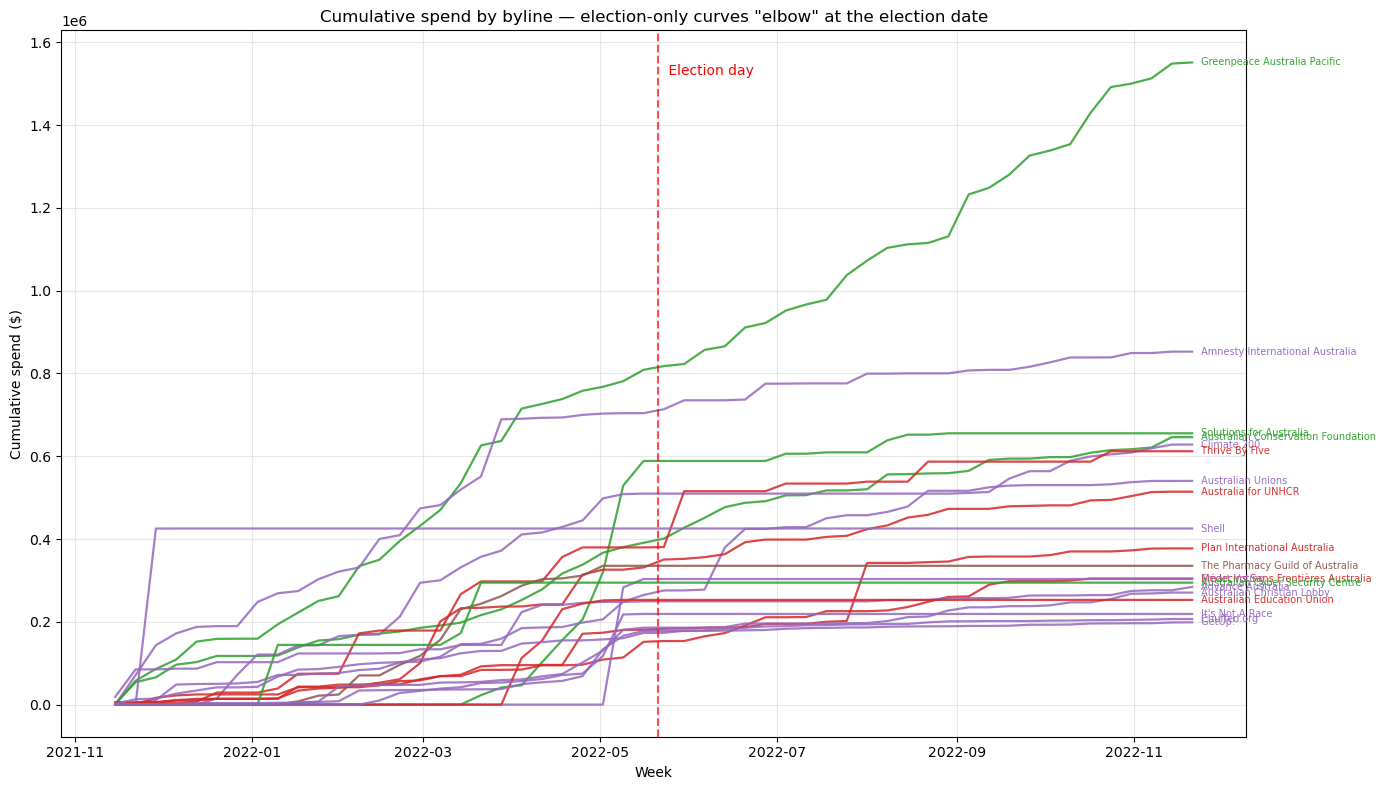

In [5]:
top20_bylines = top20['bylines'].tolist()

# Weekly aggregation per byline — cached on driver as pandas, reused by every chart below.
weekly = (v3
    .filter(col('bylines').isin(top20_bylines) & col('spend_mid').isNotNull())
    .withColumn('week', date_trunc('week', 'ad_creation_date'))
    .groupBy('week', 'bylines', 'group')
    .agg(spark_sum('spend_mid').alias('spend'))
    .orderBy('week')
    .toPandas())

# Pivot to byline × week (used by stacked/cumulative/heatmap charts below).
pivot = weekly.pivot_table(index='week', columns='bylines', values='spend', aggfunc='sum').fillna(0)
col_order = pivot.sum().sort_values(ascending=False).index.tolist()
pivot = pivot[col_order]
byline_group = dict(zip(top20['bylines'], top20['group']))

# Cumulative spend per byline — the elbow tells the story.
cumulative = pivot.cumsum()

fig, ax = plt.subplots(figsize=(14, 8))
for byline in cumulative.columns:
    grp = byline_group.get(byline, 'unknown')
    color = GROUP_COLORS.get(grp, '#777777')
    ax.plot(cumulative.index, cumulative[byline],
            color=color, alpha=0.85, linewidth=1.6)
    # End-of-line label
    end_val = cumulative[byline].iloc[-1]
    ax.text(cumulative.index[-1] + pd.Timedelta(days=2),
            end_val, ' ' + byline[:35],
            fontsize=7, va='center', color=color, alpha=0.95)

ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.7, linewidth=1.5)
ax.text(ELECTION_DATE + pd.Timedelta(days=2), ax.get_ylim()[1] * 0.95,
        ' Election day', color='red', va='top')
ax.set_title('Cumulative spend by byline — election-only curves "elbow" at the election date')
ax.set_xlabel('Week')
ax.set_ylabel('Cumulative spend ($)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

smooth the weekly series and compute persistence, centroid and EC off it, then assign each byline to a band.

In [ ]:
import numpy as np

HALF_WIDTH_WEEKS = 26
CENTROID_WINDOW  = 16
PERSIST_LOW      = 0.30
PERSIST_HIGH     = 0.80
SMOOTH_WINDOW    = 4

# collapse duplicate (bylines, week) rows that arise when a byline appears in
# more than one group, so the multi-index reindex below is unique.
weekly = (weekly
    .groupby(['bylines', 'week'], as_index=False)['spend'].sum())

# rebuild on a complete week index per byline so the rolling window sees
# zero-spend weeks instead of skipping them.
all_weeks = pd.date_range(weekly['week'].min(), weekly['week'].max(), freq='W-MON')
bylines_in_weekly = weekly['bylines'].unique()
full_index = pd.MultiIndex.from_product([bylines_in_weekly, all_weeks],
                                         names=['bylines', 'week'])
weekly = (weekly.set_index(['bylines', 'week'])
                .reindex(full_index, fill_value=0.0)
                .reset_index()
                .sort_values(['bylines', 'week']))

# re-attach group from top20.
weekly = weekly.merge(top20[['bylines', 'group']], on='bylines', how='left')

# 4-week centred rolling mean per byline, with a hard boundary at election day —
# pre and post are smoothed separately so a cliff-edged advertiser's final
# pre-election spike doesn't bleed forward into the post-election weeks.
weekly['is_post'] = weekly['week'] >= ELECTION_DATE
weekly['spend_smooth'] = (weekly.groupby(['bylines', 'is_post'])['spend']
    .transform(lambda s: s.rolling(window=SMOOTH_WINDOW, center=True, min_periods=1).mean()))

# triangle weights for the EC index.
weekly['weeks_from_election'] = (weekly['week'] - ELECTION_DATE).dt.days / 7
weekly['weight'] = np.clip(
    1.0 - np.abs(weekly['weeks_from_election']) / HALF_WIDTH_WEEKS,
    a_min=0.0, a_max=None,
)
weekly['weighted_spend_smooth'] = weekly['weight'] * weekly['spend_smooth']

# recompute persistence, EC, centroid from the smoothed series.
def _summary(x):
    total = x['spend_smooth'].sum()
    if total <= 0:
        return pd.Series({'pre_spend_s': 0.0, 'post_spend_s': 0.0,
                          'ec_index': 0.0, 'centroid_weeks': 0.0})
    pre = x.loc[~x['is_post'], 'spend_smooth'].sum()
    post = x.loc[x['is_post'], 'spend_smooth'].sum()
    return pd.Series({
        'pre_spend_s':    pre,
        'post_spend_s':   post,
        'ec_index':       x['weighted_spend_smooth'].sum() / total,
        'centroid_weeks': (x['weeks_from_election'] * x['spend_smooth']).sum() / total,
    })

smoothed = weekly.groupby('bylines').apply(_summary).reset_index()
smoothed['persistence'] = smoothed['post_spend_s'] / smoothed['pre_spend_s'].replace(0, pd.NA)

for c in ('persistence', 'ec_index', 'centroid_weeks', 'band'):
    if c in top20.columns:
        top20 = top20.drop(columns=[c])
top20 = top20.merge(
    smoothed[['bylines', 'persistence', 'ec_index', 'centroid_weeks']],
    on='bylines', how='left',
)

def _classify(row):
    p = row['persistence'] if pd.notna(row['persistence']) else 0.0
    c = abs(row['centroid_weeks']) if pd.notna(row['centroid_weeks']) else 0.0
    if p < PERSIST_LOW and c > CENTROID_WINDOW:
        return 'off_campaign'
    if p < PERSIST_LOW:
        return 'election_only'
    if p > PERSIST_HIGH:
        return 'ongoing'
    return 'transitional'

top20['band'] = top20.apply(_classify, axis=1)
top20['band'] = pd.Categorical(
    top20['band'],
    categories=['election_only', 'transitional', 'ongoing', 'off_campaign'],
    ordered=True,
)

display_cols = ['bylines', 'group', 'pre_spend', 'post_spend',
                'persistence', 'ec_index', 'centroid_weeks', 'band']
top20.sort_values(['band', 'total_spend'], ascending=[True, False])[display_cols]

stacked area of weekly spend across the top 20.

In [ ]:
pivot_smooth = (weekly.pivot_table(index='week', columns='bylines',
                                    values='spend_smooth', aggfunc='sum')
                       .fillna(0)
                       [pivot.columns])  # same byline order as the raw pivot

fig, ax = plt.subplots(figsize=(14, 8))
pivot_smooth.plot.area(ax=ax, alpha=0.85, linewidth=0, colormap='tab20')
ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.9, linewidth=1.5)
ax.text(ELECTION_DATE + pd.Timedelta(days=2), ax.get_ylim()[1] * 0.95,
        ' Election day', color='red', va='top')
ax.set_title('Weekly spend (smoothed) — stacked area, top 20 advocacy advertisers')
ax.set_ylabel('Spend ($)')
ax.set_xlabel('Week')
ax.legend(loc='upper right', fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

small multiples, one panel per byline, grouped by band. shared x, independent y.

In [ ]:
import math

# Full time window for sharex.
x_min = weekly['week'].min()
x_max = weekly['week'].max()

for band_name in ['election_only', 'transitional', 'ongoing', 'off_campaign']:
    band_data = top20[top20['band'] == band_name].sort_values('total_spend', ascending=False).reset_index(drop=True)
    n = len(band_data)
    if n == 0:
        print(f'No advertisers in band "{band_name}".\n')
        continue

    ncols = min(4, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5 * nrows),
                             squeeze=False, sharex=True, sharey=False)
    axes = axes.flatten()

    for i, row in band_data.iterrows():
        ax = axes[i]
        byline = row['bylines']
        grp = row['group']
        color = GROUP_COLORS.get(grp, '#777777')
        sub = weekly[weekly['bylines'] == byline].sort_values('week')
        ax.plot(sub['week'], sub['spend'], color=color, linewidth=1.3)
        ax.fill_between(sub['week'], sub['spend'], color=color, alpha=0.3)
        ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.5)
        ax.set_title(f'{byline[:32]}\n({grp}, ${row["total_spend"]:,.0f}, EC={row["ec_index"]:.2f})', fontsize=8)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(alpha=0.3)
        ax.set_xlim(x_min, x_max)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Weekly spend — {band_name} band ({n} advertisers)', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

quadrant scatter. x is spend imbalance (post − pre over total), y is centroid timing. bubble area is total spend, colour is band.

In [ ]:
# temporal-pattern quadrant — spend imbalance (x) × centroid timing (y), both ±1.

BAND_COLORS = {
    'election_only':   '#1f77b4',   # blue
    'transitional':    '#ff7f0e',   # orange
    'ongoing':         '#2ca02c',   # green
    'off_campaign':    '#d62728',   # red
}

# axes — signed, normalised to ±1.
total = (top20['pre_spend'] + top20['post_spend']).replace(0, 1)
top20['x_imbalance'] = (top20['post_spend'] - top20['pre_spend']) / total
top20['y_centroid']  = (-top20['centroid_weeks'] / 26).clip(-1, 1)   # +ve = pre, −ve = post


def plot_quadrant(data, size_col, size_divisor, ref_sizes, size_legend_title,
                  size_label_fmt, chart_title):
    fig, ax = plt.subplots(figsize=(13, 11))

    ax.axhline(0, color='gray', linestyle='-', alpha=0.4, linewidth=1)
    ax.axvline(0, color='gray', linestyle='-', alpha=0.4, linewidth=1)

    sizes = data[size_col] / size_divisor
    colors = data['band'].astype(str).map(BAND_COLORS)
    ax.scatter(
        data['x_imbalance'], data['y_centroid'],
        s=sizes, c=colors, alpha=0.75,
        edgecolors='black', linewidths=0.5, zorder=3,
    )

    # labels — adjustText pushes them off the bubbles with leader lines.
    texts = [
        ax.text(row['x_imbalance'], row['y_centroid'], row['bylines'][:22],
                fontsize=7.5, alpha=0.95, zorder=5)
        for _, row in data.iterrows()
    ]

    try:
        from adjustText import adjust_text
        adjust_text(
            texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5, lw=0.6),
            expand_points=(2.0, 2.0),
            expand_text=(1.4, 1.6),
            force_points=(0.6, 0.8),
            force_text=(0.7, 0.9),
            lim=500,
            only_move={'points': 'xy', 'text': 'xy', 'objects': 'xy'},
        )
    except ImportError:
        from matplotlib import patheffects
        for t in texts:
            t.set_path_effects([patheffects.withStroke(linewidth=2.0, foreground='white')])

    # quadrant labels.
    ax.text(-0.97,  0.97, 'pre-bias spending\npre-election centroid\n(off-campaign / election-only)',
            ha='left',  va='top',    fontsize=8, alpha=0.45, fontstyle='italic')
    ax.text( 0.97,  0.97, 'post-bias spending\npre-election centroid\n(rare)',
            ha='right', va='top',    fontsize=8, alpha=0.45, fontstyle='italic')
    ax.text(-0.97, -0.97, 'pre-bias spending\npost-election centroid\n(rare)',
            ha='left',  va='bottom', fontsize=8, alpha=0.45, fontstyle='italic')
    ax.text( 0.97, -0.97, 'post-bias spending\npost-election centroid\n(post-only)',
            ha='right', va='bottom', fontsize=8, alpha=0.45, fontstyle='italic')

    ax.text(-1.05,  0.02, '← all pre-election',     ha='right', va='bottom', fontsize=8, color='gray', fontstyle='italic')
    ax.text( 1.05,  0.02, 'all post-election →',    ha='left',  va='bottom', fontsize=8, color='gray', fontstyle='italic')
    ax.text( 0.02,  1.05, '↑ centroid pre-election',  ha='left', va='bottom', fontsize=8, color='gray', fontstyle='italic')
    ax.text( 0.02, -1.05, '↓ centroid post-election', ha='left', va='top',    fontsize=8, color='gray', fontstyle='italic')

    from matplotlib.lines import Line2D
    band_handles = [
        Line2D([0], [0], marker='o', linestyle='', color='w',
               markerfacecolor=c, markeredgecolor='black', markersize=10, label=b)
        for b, c in BAND_COLORS.items()
    ]
    # Line2D markersize is diameter in points → 2 * sqrt(area / pi).
    size_handles = [
        Line2D([0], [0], marker='o', linestyle='', color='w',
               markerfacecolor='lightgray', markeredgecolor='black',
               markersize=2 * np.sqrt((s / size_divisor) / np.pi),
               label=size_label_fmt(s))
        for s in ref_sizes
    ]
    band_legend = ax.legend(handles=band_handles, loc='lower left', fontsize=9,
                            framealpha=0.9, title='Band')
    ax.add_artist(band_legend)
    ax.legend(handles=size_handles, loc='lower right', fontsize=8, framealpha=0.9,
              title=size_legend_title, labelspacing=1.6)

    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xlabel('Spend imbalance:  (post − pre) / (post + pre)')
    ax.set_ylabel('Centroid timing  (pre-election ↑ / post-election ↓)')
    ax.set_title(chart_title)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()


plot_quadrant(
    top20,
    size_col='total_spend',
    size_divisor=2000,
    ref_sizes=[200_000, 500_000, 1_500_000],
    size_legend_title='Total spend',
    size_label_fmt=lambda s: f'${s:,.0f}',
    chart_title='Top 20 — temporal spending pattern  (bubble area ∝ total spend)',
)

same quadrant, bubble area is impressions instead of spend. comparison table at the end for spend rank vs impression rank.

In [ ]:
# aggregate total impressions per top-20 byline from v3.
imp_pdf = (v3
    .filter(col('bylines').isin(top20_bylines) & col('impressions_mid').isNotNull())
    .groupBy('bylines')
    .agg(spark_sum('impressions_mid').alias('total_impressions'))
    .toPandas())

top20_imp = top20.merge(imp_pdf, on='bylines', how='left')
top20_imp['total_impressions'] = top20_imp['total_impressions'].fillna(0)

# scale so the biggest bubble is similar to the spend chart.
imp_divisor = top20_imp['total_impressions'].max() / 1500
imp_max = top20_imp['total_impressions'].max()

plot_quadrant(
    top20_imp,
    size_col='total_impressions',
    size_divisor=imp_divisor,
    ref_sizes=[imp_max * 0.1, imp_max * 0.4, imp_max],
    size_legend_title='Total impressions',
    size_label_fmt=lambda s: f'{s/1e6:,.1f}M imp',
    chart_title='Top 20 — temporal pattern  (bubble area ∝ total impressions)',
)

# spend rank vs impression rank.
cmp = top20_imp[['bylines', 'total_spend', 'total_impressions']].copy()
cmp['spend_rank'] = cmp['total_spend'].rank(ascending=False).astype(int)
cmp['imp_rank']   = cmp['total_impressions'].rank(ascending=False).astype(int)
cmp['cpm']        = cmp['total_spend'] / (cmp['total_impressions'] / 1000).replace(0, pd.NA)
cmp['rank_shift'] = cmp['spend_rank'] - cmp['imp_rank']
cmp.sort_values('rank_shift')[['bylines', 'spend_rank', 'imp_rank', 'rank_shift', 'cpm']]

roll up to bands. count, total spend, mean persistence and EC per band.

In [ ]:
band_summary = top20.groupby('band', observed=True).agg(
    n_advertisers=('bylines', 'count'),
    pre_spend=('pre_spend', 'sum'),
    post_spend=('post_spend', 'sum'),
    total_spend=('total_spend', 'sum'),
    mean_persistence=('persistence', 'mean'),
    mean_ec=('ec_index', 'mean'),
).reset_index()

band_summary['total_share'] = band_summary['total_spend'] / band_summary['total_spend'].sum()

band_summary

the advocacy ecosystem splits into four patterns, with election_only the biggest by count and greenpeace dominating the ongoing band. shell only shows up as off_campaign once you combine persistence with centroid.

In [ ]:
for each of the three main bands (election_only, transitional, ongoing), show every advertiser and their top 5 keywords from ad body + title text. regex tokenise, lowercase, drop stopwords.

from pyspark.sql.functions import (
    row_number, explode, lower, regexp_replace, split, length,
    concat_ws, array_join, collect_list,
)
from pyspark.sql.window import Window
from pyspark.ml.feature import StopWordsRemover

# english stopwords plus a few domain words that don't differentiate australian
# political advocacy bylines (everyone says 'australia', 'sign', etc).
STOP = set(StopWordsRemover.loadDefaultStopWords('english')) | {
    'australia', 'australian', 'australians', 'sign', 'petition', 'please',
    'today', 'help', 'support', 'make', 'get', 'one', 'us', 'go',
    'http', 'https', 'www', 'com', 'au',
}

top_keywords_by_band = {}
for band_name in ['election_only', 'transitional', 'ongoing']:
    band_bylines = top20.loc[top20['band'] == band_name, 'bylines'].tolist()
    if not band_bylines:
        top_keywords_by_band[band_name] = pd.DataFrame()
        continue

    # combine body + title arrays into one text blob per ad, tokenise.
    tokens = (v3
        .filter(col('bylines').isin(band_bylines))
        .withColumn('text', concat_ws(' ',
            array_join('creative_bodies', ' '),
            array_join('creative_link_titles', ' ')))
        .withColumn('text', lower(regexp_replace('text', r'[^a-z\s]', ' ')))
        .withColumn('token', explode(split(col('text'), r'\s+')))
        .filter(length('token') > 2)
        .filter(~col('token').isin(list(STOP))))

    counts = tokens.groupBy('bylines', 'token').count()
    w = Window.partitionBy('bylines').orderBy(desc('count'), 'token')
    top5 = (counts
        .withColumn('rn', row_number().over(w))
        .filter(col('rn') <= 5)
        .orderBy('bylines', 'rn')
        .groupBy('bylines')
        .agg(collect_list('token').alias('top_keywords'))
        .toPandas())

    # preserve band ordering by total spend.
    order = (top20.loc[top20['band'] == band_name]
                  .sort_values('total_spend', ascending=False)['bylines']
                  .tolist())
    top5['_order'] = top5['bylines'].map({b: i for i, b in enumerate(order)})
    top5 = top5.sort_values('_order').drop(columns='_order').reset_index(drop=True)
    top5['top_keywords'] = top5['top_keywords'].apply(lambda xs: ', '.join(xs))
    top_keywords_by_band[band_name] = top5

for band_name, df in top_keywords_by_band.items():
    print(f'\n=== {band_name} ({len(df)} advertisers) ===')
    display(df)